# =========================================================
# PHASE 9: STATISTICS
# SUPPLY CHAIN ANALYTICS PLATFORM
# =========================================================

# MODULES COVERED:
# 1. Data Loading
# 2. Descriptive Statistics
# 3. Distribution Analysis
# 4. Correlation Analysis
# 5. Probability & Z-Score
# 6. Hypothesis Testing
# 7. Confidence Intervals
# 8. Statistical Business Insights
# =========================================================

In [2]:
# =========================================================
# MODULE 0: IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
import os

print(os.getcwd())

C:\Users\DELL


In [10]:
df = pd.read_csv(r"C:\Projects\Supply Chain Analytics Platform\Supply Chain Analytics Platform File\SupplyChain_Cleaned.csv")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Status,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Order Quarter,Shipping Delay,On Time Delivery,Profit Margin %,Delivery Performance
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-02-03 22:56:00,Standard Class,2018,1,1,-1,Yes,27.841342,Early
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,0,2018-01-18 12:27:00,Standard Class,2018,1,1,1,No,-75.999999,Late
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,0,2018-01-17 12:06:00,Standard Class,2018,1,1,0,Yes,-75.600305,On Time
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,0,2018-01-16 11:45:00,Standard Class,2018,1,1,-1,Yes,6.974829,Early
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-01-15 11:24:00,Standard Class,2018,1,1,-2,Yes,40.948896,Early


In [12]:
df.shape

(180519, 58)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 58 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [16]:
df.isnull().sum().sum()

0

In [18]:
# Main numerical columns for statistics

stats_cols = [
    'Sales',
    'Order Profit Per Order',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Shipping Delay',
    'Profit Margin %'
]

df[stats_cols].head()

,Sales,Order Profit Per Order,Order Item Quantity,Order Item Discount Rate,Shipping Delay,Profit Margin %
0,327.75,91.250000,1,0.04,-1,27.841342
1,327.75,-249.089996,1,0.05,1,-75.999999
2,327.75,-247.779999,1,0.06,0,-75.600305
3,327.75,22.860001,1,0.07,-1,6.974829
4,327.75,134.210007,1,0.09,-2,40.948896


In [20]:
# =========================================================
# MODULE 2: DESCRIPTIVE STATISTICS
# =========================================================

descriptive_stats = df[stats_cols].describe().T

descriptive_stats['range'] = descriptive_stats['max'] - descriptive_stats['min']
descriptive_stats['variance'] = df[stats_cols].var()
descriptive_stats['median'] = df[stats_cols].median()
descriptive_stats['mode'] = df[stats_cols].mode().iloc[0]
descriptive_stats['iqr'] = descriptive_stats['75%'] - descriptive_stats['25%']

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,range,variance,median,mode,iqr
Sales,180519.0,203.772096,132.273077,9.990000,119.980003,199.919998,299.950012,1999.989990,1989.999990,17496.167031,199.919998,129.990005,179.970009
Order Profit Per Order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988,5186.779968,10906.361300,31.520000,0.000000,57.800003
Order Item Quantity,180519.0,2.127638,1.453451,1.000000,1.000000,1.000000,3.000000,5.000000,4.000000,2.112521,1.000000,1.000000,2.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.000000,0.040000,0.100000,0.160000,0.250000,0.250000,0.004958,0.100000,0.030000,0.120000
Shipping Delay,180519.0,0.565807,1.490966,-2.000000,0.000000,1.000000,1.000000,4.000000,6.000000,2.222980,1.000000,1.000000,1.000000
Profit Margin %,180519.0,10.832612,42.059372,-274.999998,6.224000,24.251212,33.601431,50.044288,325.044286,1768.990761,24.251212,0.000000,27.377431


In [22]:
# Percentiles

percentiles = df[stats_cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95]).T
percentiles

,0.25,0.50,0.75,0.90,0.95
Sales,119.980003,199.919998,299.950012,399.980011,399.980011
Order Profit Per Order,7.000000,31.520000,64.800003,105.190002,132.289993
Order Item Quantity,1.000000,1.000000,3.000000,5.000000,5.000000
Order Item Discount Rate,0.040000,0.100000,0.160000,0.200000,0.250000
Shipping Delay,0.000000,1.000000,1.000000,2.000000,3.000000
Profit Margin %,6.224000,24.251212,33.601431,42.303254,45.360001


In [24]:
# Business Summary

for col in stats_cols:
    print("="*60)
    print(f"Metric: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Minimum: {df[col].min():.2f}")
    print(f"Maximum: {df[col].max():.2f}")

Metric: Sales
Mean: 203.77
Median: 199.92
Standard Deviation: 132.27
Minimum: 9.99
Maximum: 1999.99
Metric: Order Profit Per Order
Mean: 21.97
Median: 31.52
Standard Deviation: 104.43
Minimum: -4274.98
Maximum: 911.80
Metric: Order Item Quantity
Mean: 2.13
Median: 1.00
Standard Deviation: 1.45
Minimum: 1.00
Maximum: 5.00
Metric: Order Item Discount Rate
Mean: 0.10
Median: 0.10
Standard Deviation: 0.07
Minimum: 0.00
Maximum: 0.25
Metric: Shipping Delay
Mean: 0.57
Median: 1.00
Standard Deviation: 1.49
Minimum: -2.00
Maximum: 4.00
Metric: Profit Margin %
Mean: 10.83
Median: 24.25
Standard Deviation: 42.06
Minimum: -275.00
Maximum: 50.04


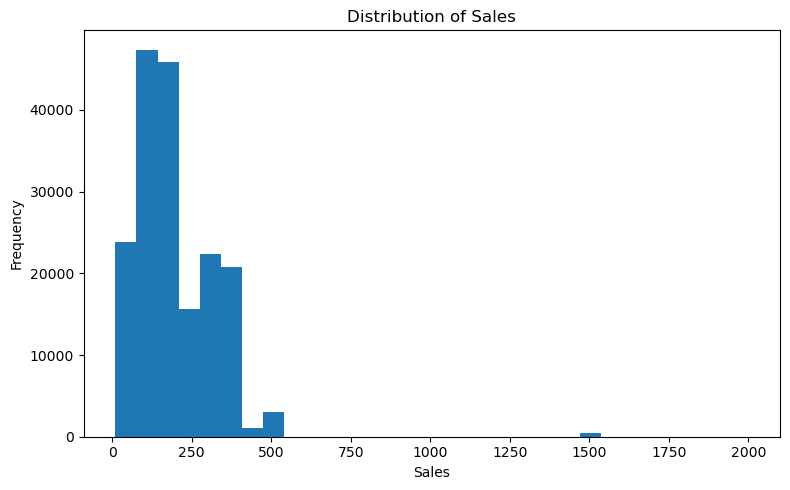

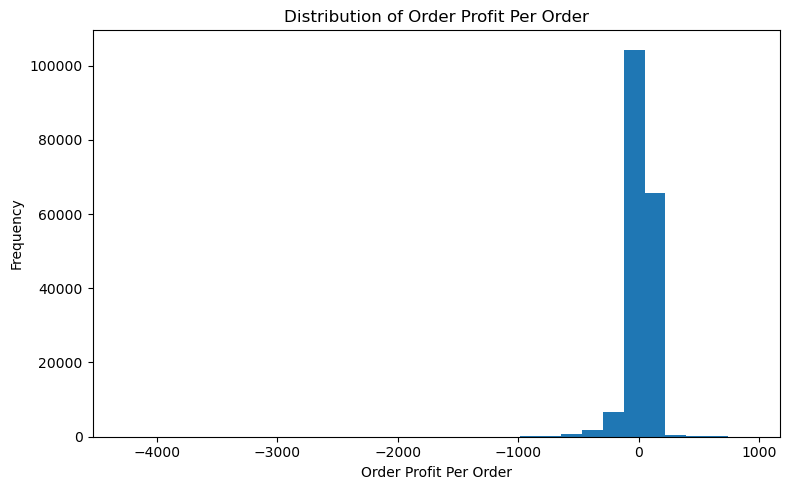

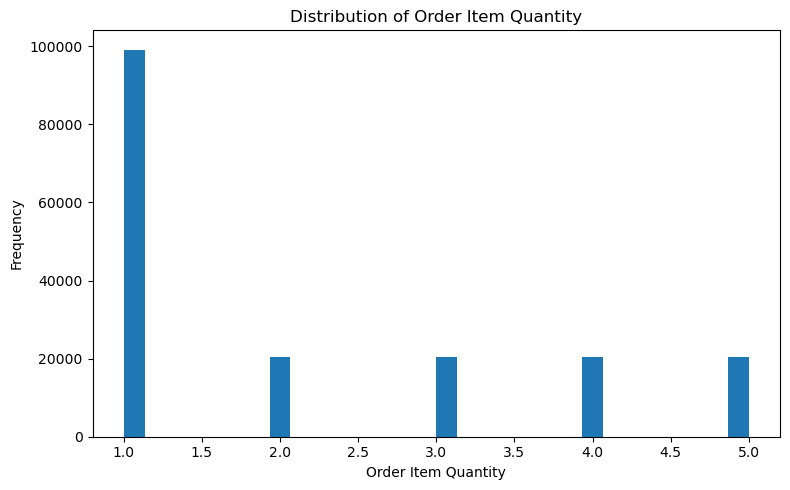

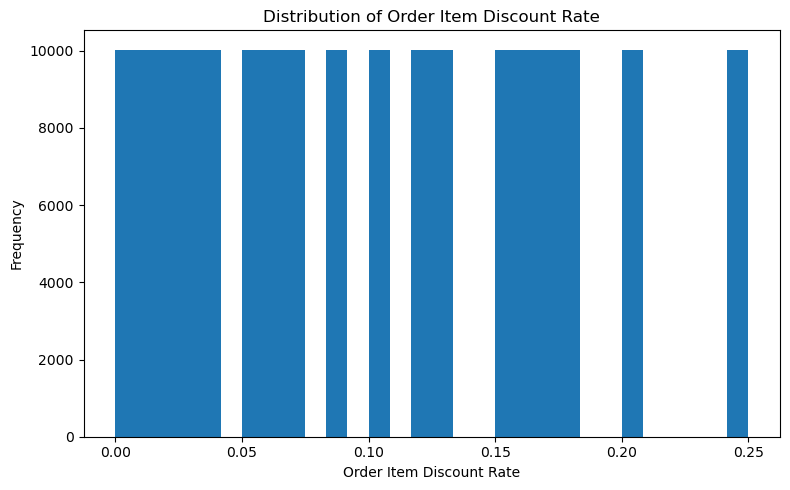

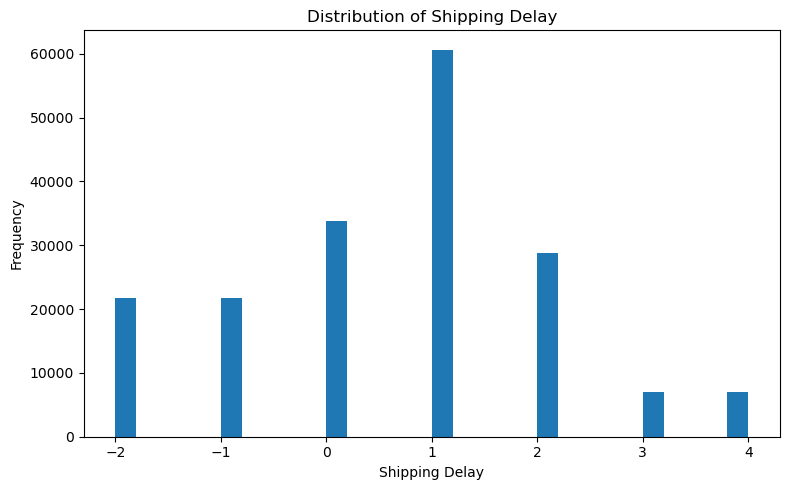

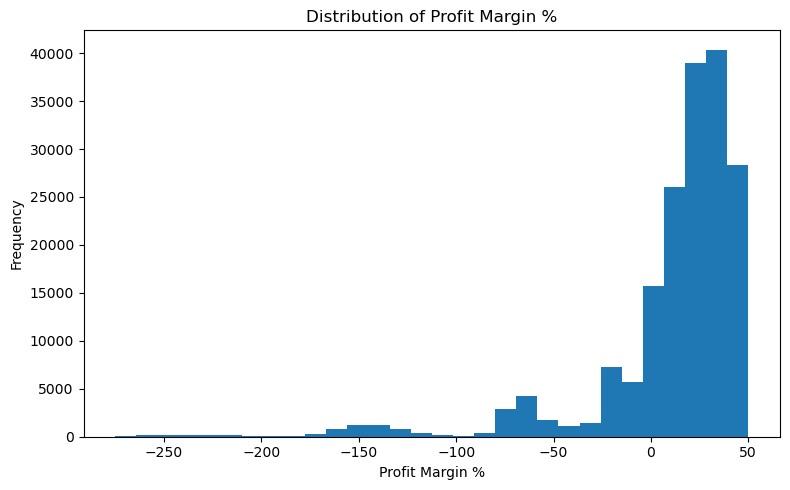

In [26]:
# =========================================================
# MODULE 3: DISTRIBUTION ANALYSIS
# =========================================================

for col in stats_cols:
    plt.figure(figsize=(8,5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

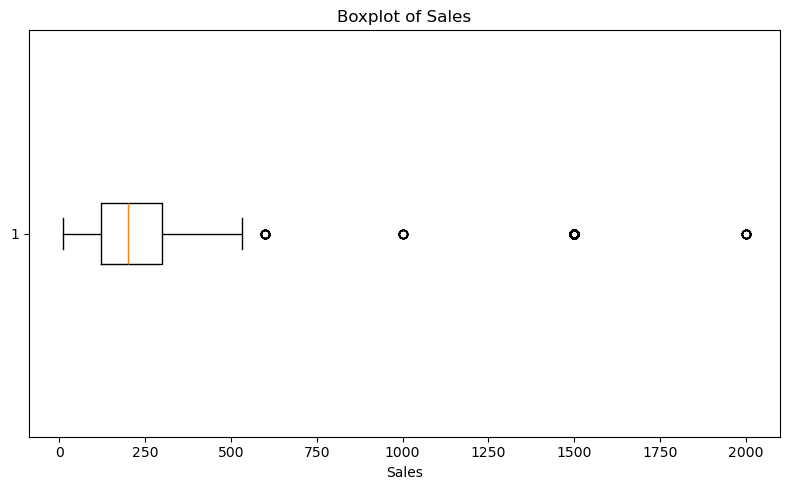

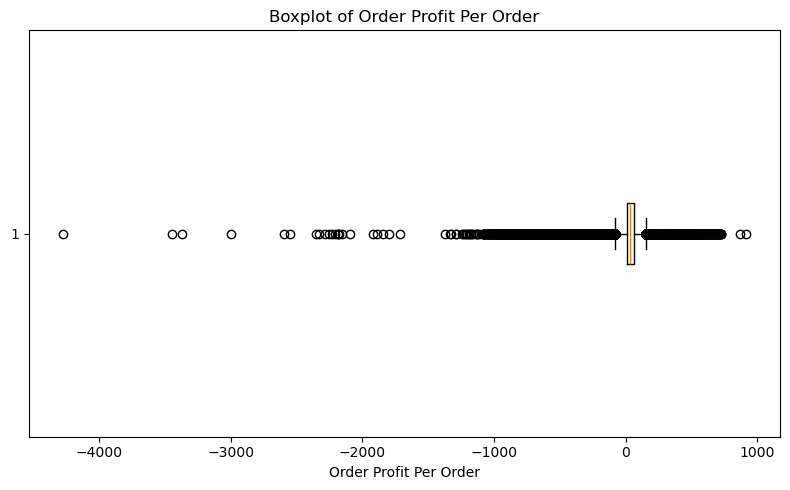

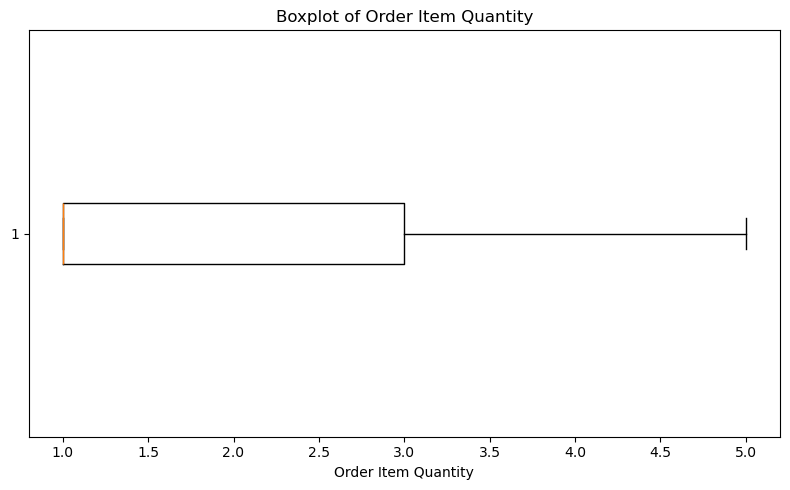

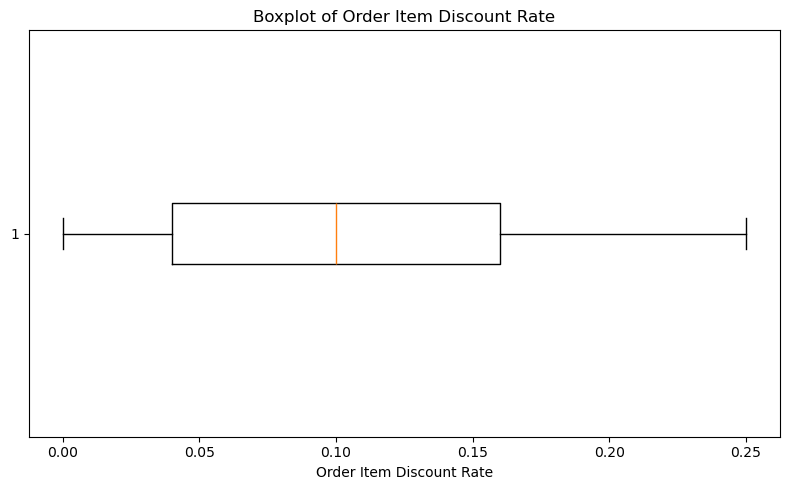

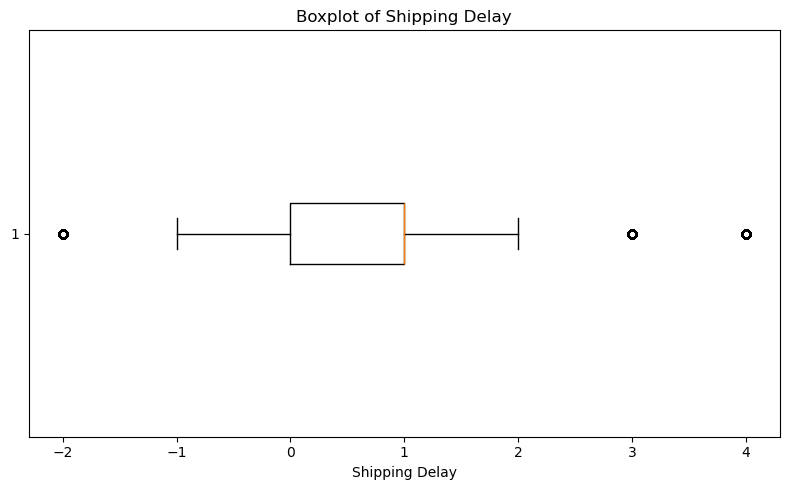

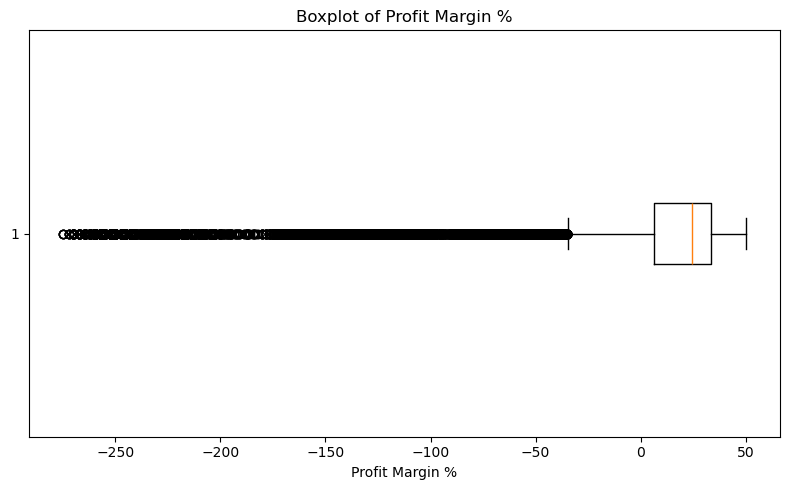

In [28]:
# Boxplots for outlier view

for col in stats_cols:
    plt.figure(figsize=(8,5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [30]:
# Skewness and Kurtosis

distribution_stats = pd.DataFrame({
    'skewness': df[stats_cols].skew(),
    'kurtosis': df[stats_cols].kurtosis()
})

distribution_stats

,skewness,kurtosis
Sales,2.884249,23.936561
Order Profit Per Order,-4.741834,71.377259
Order Item Quantity,0.880252,-0.753702
Order Item Discount Rate,0.340928,-0.901157
Shipping Delay,0.031464,-0.292237
Profit Margin %,-2.910850,10.434084


In [32]:
# Outlier Detection using IQR

outlier_summary = []

for col in stats_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        'column': col,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,Sales,-149.975010,569.905025,488,0.27
1,Order Profit Per Order,-79.700005,151.500008,18942,10.49
2,Order Item Quantity,-2.000000,6.000000,0,0.00
3,Order Item Discount Rate,-0.140000,0.340000,0,0.00
4,Shipping Delay,-1.500000,2.500000,35701,19.78
5,Profit Margin %,-34.842147,74.667578,16829,9.32


In [34]:
# =========================================================
# MODULE 4: CORRELATION ANALYSIS
# =========================================================

correlation_matrix = df[stats_cols].corr()
correlation_matrix

,Sales,Order Profit Per Order,Order Item Quantity,Order Item Discount Rate,Shipping Delay,Profit Margin %
Sales,1.000000,0.131816,0.106442,0.000346,-0.003695,-0.001777
Order Profit Per Order,0.131816,1.000000,0.015696,-0.018644,-0.005385,0.826243
Order Item Quantity,0.106442,0.015696,1.000000,-0.000028,0.001813,0.001374
Order Item Discount Rate,0.000346,-0.018644,-0.000028,1.000000,0.001537,-0.023094
Shipping Delay,-0.003695,-0.005385,0.001813,0.001537,1.000000,-0.003441
Profit Margin %,-0.001777,0.826243,0.001374,-0.023094,-0.003441,1.000000


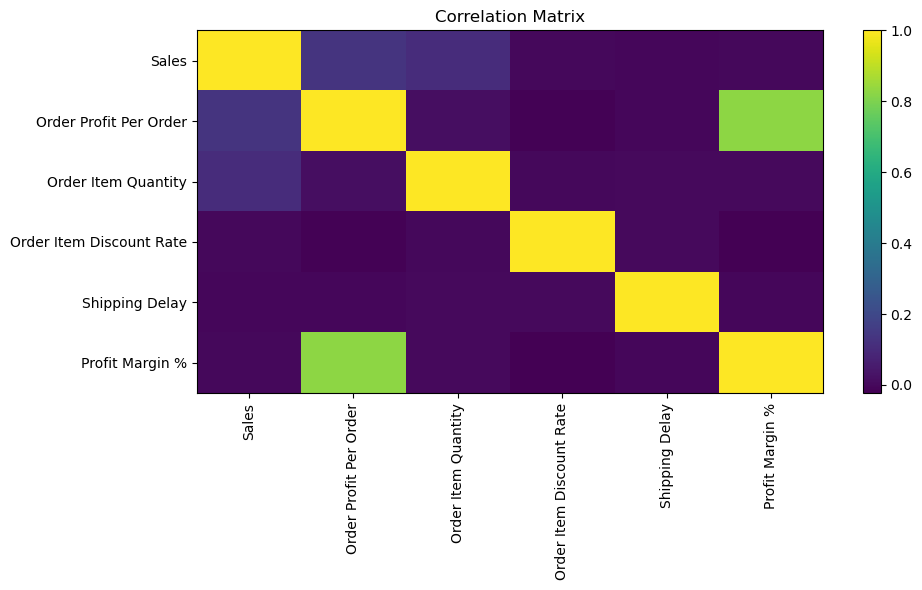

In [36]:
plt.figure(figsize=(10,6))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [38]:
# Strong Correlations

corr_pairs = correlation_matrix.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()

strong_corr = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr'])

strong_corr.head(10)

,Variable 1,Variable 2,Correlation,abs_corr
31,Profit Margin %,Order Profit Per Order,0.826243,0.826243
1,Sales,Order Profit Per Order,0.131816,0.131816
2,Sales,Order Item Quantity,0.106442,0.106442
23,Order Item Discount Rate,Profit Margin %,-0.023094,0.023094
19,Order Item Discount Rate,Order Profit Per Order,-0.018644,0.018644
8,Order Profit Per Order,Order Item Quantity,0.015696,0.015696
25,Shipping Delay,Order Profit Per Order,-0.005385,0.005385
24,Shipping Delay,Sales,-0.003695,0.003695
29,Shipping Delay,Profit Margin %,-0.003441,0.003441
16,Order Item Quantity,Shipping Delay,0.001813,0.001813


In [40]:
# =========================================================
# MODULE 5: PROBABILITY & Z-SCORE ANALYSIS
# =========================================================

# Z-score for Sales

df['sales_zscore'] = stats.zscore(df['Sales'])

df[['Sales', 'sales_zscore']].head()

,Sales,sales_zscore
0,327.75,0.93729
1,327.75,0.93729
2,327.75,0.93729
3,327.75,0.93729
4,327.75,0.93729


In [42]:
# Orders with unusually high sales: Z-score > 2

high_sales_outliers = df[df['sales_zscore'] > 2]

high_sales_outliers[['Sales', 'sales_zscore']].head()

,Sales,sales_zscore
120,499.950012,2.239146
121,499.950012,2.239146
122,499.950012,2.239146
123,499.950012,2.239146
124,499.950012,2.239146


In [44]:
high_sales_outliers.shape

(3538, 59)

In [46]:
# Probability that an order is late

late_probability = (df['Delivery Performance'] == 'Late').mean()

print(f"Probability of Late Delivery: {late_probability:.2%}")

Probability of Late Delivery: 57.28%


In [48]:
# Probability that an order is on time

on_time_probability = (df['Delivery Performance'] == 'On Time').mean()

print(f"Probability of On-Time Delivery: {on_time_probability:.2%}")

Probability of On-Time Delivery: 18.70%


In [50]:
# Probability that profit is negative

negative_profit_probability = (df['Order Profit Per Order'] < 0).mean()

print(f"Probability of Negative Profit Order: {negative_profit_probability:.2%}")

Probability of Negative Profit Order: 18.71%


In [52]:
# =========================================================
# MODULE 6: HYPOTHESIS TESTING
# =========================================================

In [54]:
# Test 1:
# Do Late deliveries have different profit margins compared to On-Time deliveries?

late_profit_margin = df[df['Delivery Performance'] == 'Late']['Profit Margin %']
ontime_profit_margin = df[df['Delivery Performance'] == 'On Time']['Profit Margin %']

t_stat, p_value = stats.ttest_ind(
    late_profit_margin,
    ontime_profit_margin,
    equal_var=False
)

print("T-Test: Late vs On-Time Profit Margin")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference.")
else:
    print("Result: No statistically significant difference.")

T-Test: Late vs On-Time Profit Margin
T-statistic: -1.3202
P-value: 0.1868
Result: No statistically significant difference.


In [56]:
# Test 2:
# Do different customer segments have different average sales?

consumer_sales = df[df['Customer Segment'] == 'Consumer']['Sales']
corporate_sales = df[df['Customer Segment'] == 'Corporate']['Sales']
home_office_sales = df[df['Customer Segment'] == 'Home Office']['Sales']

f_stat, p_value = stats.f_oneway(
    consumer_sales,
    corporate_sales,
    home_office_sales
)

print("ANOVA Test: Sales by Customer Segment")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: At least one customer segment has significantly different sales.")
else:
    print("Result: No significant sales difference between customer segments.")

ANOVA Test: Sales by Customer Segment
F-statistic: 2.4491
P-value: 0.0864
Result: No significant sales difference between customer segments.


In [60]:
# Test 3:
# Chi-Square Test: Is Delivery Performance associated with Shipping Mode?

contingency_table = pd.crosstab(df['Shipping Mode'], df['Delivery Performance'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Test: Shipping Mode vs Delivery Performance")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Shipping Mode and Delivery Performance are associated.")
else:
    print("Result: No significant association.")

Chi-Square Test: Shipping Mode vs Delivery Performance
Chi-square statistic: 58345.4236
P-value: 0.0000
Result: Shipping Mode and Delivery Performance are associated.


In [62]:
contingency_table

Delivery Performance,Early,Late,On Time
Shipping Mode,,,
First Class,0,27814,0
Same Day,0,4657,5080
Second Class,0,28078,7138
Standard Class,43366,42851,21535


In [64]:
# =========================================================
# MODULE 7: CONFIDENCE INTERVALS
# =========================================================

def confidence_interval(data, confidence=0.95):
    data = data.dropna()
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2., len(data)-1)
    return mean, mean - margin, mean + margin

for col in ['Sales', 'Order Profit Per Order', 'Shipping Delay', 'Profit Margin %']:
    mean, lower, upper = confidence_interval(df[col])
    print("="*60)
    print(f"Metric: {col}")
    print(f"Mean: {mean:.2f}")
    print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Metric: Sales
Mean: 203.77
95% Confidence Interval: (203.16, 204.38)
Metric: Order Profit Per Order
Mean: 21.97
95% Confidence Interval: (21.49, 22.46)
Metric: Shipping Delay
Mean: 0.57
95% Confidence Interval: (0.56, 0.57)
Metric: Profit Margin %
Mean: 10.83
95% Confidence Interval: (10.64, 11.03)


In [66]:
# =========================================================
# MODULE 8: STATISTICAL BUSINESS INSIGHTS
# =========================================================

In [68]:
# Insight 1: Revenue variability

sales_mean = df['Sales'].mean()
sales_std = df['Sales'].std()
sales_cv = sales_std / sales_mean

print(f"Average Sales: {sales_mean:.2f}")
print(f"Sales Standard Deviation: {sales_std:.2f}")
print(f"Sales Coefficient of Variation: {sales_cv:.2f}")

Average Sales: 203.77
Sales Standard Deviation: 132.27
Sales Coefficient of Variation: 0.65


In [70]:
# Insight 2: Profit variability

profit_mean = df['Order Profit Per Order'].mean()
profit_std = df['Order Profit Per Order'].std()
profit_cv = profit_std / profit_mean

print(f"Average Profit: {profit_mean:.2f}")
print(f"Profit Standard Deviation: {profit_std:.2f}")
print(f"Profit Coefficient of Variation: {profit_cv:.2f}")

Average Profit: 21.97
Profit Standard Deviation: 104.43
Profit Coefficient of Variation: 4.75


In [72]:
# Insight 3: Delivery performance summary

delivery_summary = df['Delivery Performance'].value_counts(normalize=True) * 100
delivery_summary

Delivery Performance
Late       57.279289
Early      24.022956
On Time    18.697755
Name: proportion, dtype: float64

In [74]:
# Insight 4: Average shipping delay by delivery performance

df.groupby('Delivery Performance')['Shipping Delay'].mean().sort_values(ascending=False)

Delivery Performance
Late       1.616741
On Time    0.000000
Early     -1.499608
Name: Shipping Delay, dtype: float64

In [76]:
# Insight 5: Profit margin by delivery performance

df.groupby('Delivery Performance')['Profit Margin %'].mean().sort_values(ascending=False)

Delivery Performance
On Time    11.058815
Early      10.945658
Late       10.711360
Name: Profit Margin %, dtype: float64

In [78]:
# Insight 6: Sales and profit by customer segment

customer_segment_stats = df.groupby('Customer Segment').agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    total_profit=('Order Profit Per Order', 'sum'),
    avg_profit=('Order Profit Per Order', 'mean'),
    avg_profit_margin=('Profit Margin %', 'mean')
).round(2)

customer_segment_stats

,total_sales,avg_sales,total_profit,avg_profit,avg_profit_margin
Customer Segment,,,,,
Consumer,19095790.16,204.22,2073487.67,22.18,10.89
Corporate,11168406.84,203.84,1202574.96,21.95,10.85
Home Office,6520538.02,202.34,690840.34,21.44,10.64


In [80]:
# Insight 7: Category statistical performance

category_stats = df.groupby('Category Name').agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    total_profit=('Order Profit Per Order', 'sum'),
    avg_profit=('Order Profit Per Order', 'mean'),
    quantity_sold=('Order Item Quantity', 'sum')
).round(2).sort_values(by='total_sales', ascending=False)

category_stats.head(10)

,total_sales,avg_sales,total_profit,avg_profit,quantity_sold
Category Name,,,,,
Fishing,6929653.69,399.98,756220.77,43.65,17325
Cleats,4431942.78,180.52,494636.92,20.15,73734
Camping & Hiking,4118425.57,299.98,427455.57,31.14,13729
Cardio Equipment,3694843.20,295.90,383011.10,30.67,37587
Women's Apparel,3147800.00,149.65,350421.03,16.66,62956
Water Sports,3113844.68,200.38,325146.96,20.92,15540
Men's Footwear,2891757.66,129.99,311902.82,14.02,22246
Indoor/Outdoor Games,2888993.91,149.70,318451.43,16.50,57803
Shop By Sport,1309522.04,119.22,129813.96,11.82,32726


In [82]:
# =========================================================
# FINAL STATISTICAL SUMMARY
# =========================================================

final_stats_summary = pd.DataFrame({
    'Metric': [
        'Average Sales',
        'Average Profit',
        'Average Shipping Delay',
        'Average Profit Margin %',
        'Late Delivery Probability',
        'Negative Profit Probability'
    ],
    'Value': [
        round(df['Sales'].mean(), 2),
        round(df['Order Profit Per Order'].mean(), 2),
        round(df['Shipping Delay'].mean(), 2),
        round(df['Profit Margin %'].mean(), 2),
        round((df['Delivery Performance'] == 'Late').mean() * 100, 2),
        round((df['Order Profit Per Order'] < 0).mean() * 100, 2)
    ]
})

final_stats_summary

,Metric,Value
0,Average Sales,203.77
1,Average Profit,21.97
2,Average Shipping Delay,0.57
3,Average Profit Margin %,10.83
4,Late Delivery Probability,57.28
5,Negative Profit Probability,18.71


In [84]:
# =========================================================
# SAVE STATISTICAL OUTPUTS
# =========================================================

descriptive_stats.to_csv("statistics_descriptive_summary.csv")
distribution_stats.to_csv("statistics_distribution_summary.csv")
outlier_summary_df.to_csv("statistics_outlier_summary.csv", index=False)
correlation_matrix.to_csv("statistics_correlation_matrix.csv")
final_stats_summary.to_csv("statistics_final_summary.csv", index=False)

print("Statistics outputs saved successfully.")

Statistics outputs saved successfully.
